# Extending Gridded DSS Forcing Through the Simulation Window

This notebook builds a deterministic gridded precipitation family over the real
Bald Eagle Creek RasExamples mesh, uses
`RasDss.copy_grid_with_zero_tail()` to extend the forcing through a longer
hydraulic window, and verifies the complete chain in HEC-RAS 7.0: source
immutability, derivative DSS, temporary plan HDF, completed plan HDF, and
hydraulic results.


## Scope and engineering boundary

The helper performs mechanical DSS preparation. It copies an accepted regular
grid family, can apply an explicitly reviewed fixed time/origin/pathname
translation, and appends zero-precipitation records. It does not infer time
zones, perform storm transposition, reproject/resample values, or decide how
long a model needs to drain.

`pydsstools` currently requires NumPy 1.x, so run this notebook in the same
dedicated environment described by notebooks 916 and 926. Generated DSS and
model files stay under the ignored run root; `RAS_COMMANDER_EXAMPLE_RUN_ROOT`
can provide a short local path.

Manual review of source provenance, units, period semantics, DSS pathnames,
forcing coverage, HEC-RAS messages/maps, convergence, and hydraulic plausibility
remains required.


In [1]:
# Development mode: import repository source when run from a clone.
USE_LOCAL_SOURCE = True

import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name.lower() == "examples" else Path.cwd()
if USE_LOCAL_SOURCE and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import ras_commander

print(f"ras-commander {ras_commander.__version__} ({'repository source' if USE_LOCAL_SOURCE else 'installed package'})")


ras-commander 0.102.0 (repository source)


In [2]:
from datetime import datetime, timedelta
from hashlib import sha256
import logging
import os
from pathlib import Path
import re
import subprocess

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ras_commander import (
    HdfMesh,
    HdfResultsMesh,
    HdfResultsPlan,
    RasCmdr,
    RasDss,
    RasExamples,
    RasPlan,
    RasPreprocess,
    RasUnsteady,
    get_ras_exe,
    init_ras_project,
)

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
for logger_name in ("pydsstools", "pydsstools.heclib.logging", "ras_commander"):
    logging.getLogger(logger_name).setLevel(logging.WARNING)

run_root = Path(os.environ.get(
    "RAS_COMMANDER_EXAMPLE_RUN_ROOT",
    repo_root / "working" / "example_728_dss_window_qualification",
)).resolve()
run_root.mkdir(parents=True, exist_ok=True)

def rel(path: Path) -> str:
    path = Path(path).resolve()
    try:
        return path.relative_to(repo_root.resolve()).as_posix()
    except ValueError:
        return path.name

def sha256_file(path: Path) -> str:
    digest = sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

RAS_VERSION = "7.0"
MESH_NAME = "BaldEagleCr"
TEMPLATE_PLAN = "06"
TEMPLATE_UNSTEADY = "03"
TEMPLATE_GEOMETRY = "09"
SOURCE_FAMILY = "/SHG/BALD_EAGLE_CREEK/PRECIPITATION///WINDOW-SOURCE/"
OUTPUT_FAMILY = "/SHG/BALD_EAGLE_CREEK/PRECIPITATION///WINDOW-EXTENDED/"
TAIL_INTERVALS = 3
CELL_SIZE_M = 2500.0
simulation_start = datetime(2024, 8, 1, 0)
source_end = simulation_start + timedelta(hours=2)
ras_exe = get_ras_exe(RAS_VERSION)


## Build a model-covering deterministic source DSS

The grid extent is derived from real mesh center points transformed to the
standard SHG/CONUS Albers CRS. The source has one dry context interval before
the plan starts and two spatially varying one-hour rainfall intervals. A
separate time-series record confirms that only the selected grid family is
copied.


,value
model,BaldEagleDamBrk
active computational cells,18066
result-center slots,19597
source grid shape,"(17, 17)"
source grid origin,"(1507500.0, 2135000.0)"
source records,3
source SHA-256,473d353a589b457a610378313b98f084ebfbc22f121be4...


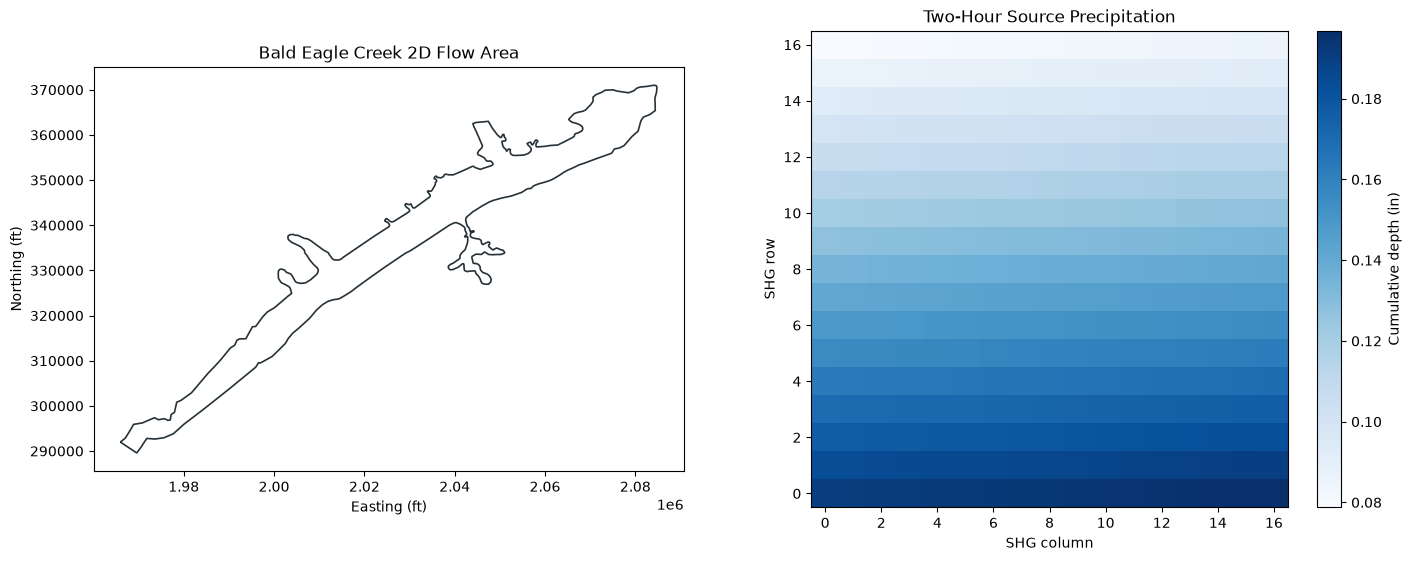

In [3]:
project_path = RasExamples.extract_project(
    "BaldEagleCrkMulti2D",
    output_path=run_root / "model",
    suffix="dss_window_qualification",
)
ras = init_ras_project(
    project_path, ras_version=RAS_VERSION,
    load_results_summary=False, hide_intro=True,
)
geometry_hdf = ras.project_folder / f"{ras.project_name}.g{TEMPLATE_GEOMETRY}.hdf"
mesh_points = HdfMesh.get_mesh_cell_points(geometry_hdf)
mesh_points = mesh_points.loc[mesh_points["mesh_name"] == MESH_NAME].sort_values("cell_id").reset_index(drop=True)
mesh_attributes = HdfMesh.get_mesh_area_attributes(geometry_hdf)
mesh_cell_count = int(np.asarray(mesh_attributes.loc["Cell Count", "Value"]).reshape(-1)[0])
mesh_shg = mesh_points.to_crs("EPSG:5070")
x = mesh_shg.geometry.x.to_numpy()
y = mesh_shg.geometry.y.to_numpy()
origin_x = np.floor(x.min() / CELL_SIZE_M) * CELL_SIZE_M - 2 * CELL_SIZE_M
origin_y = np.floor(y.min() / CELL_SIZE_M) * CELL_SIZE_M - 2 * CELL_SIZE_M
columns = int(np.ceil((x.max() + 2 * CELL_SIZE_M - origin_x) / CELL_SIZE_M))
rows = int(np.ceil((y.max() + 2 * CELL_SIZE_M - origin_y) / CELL_SIZE_M))

source_dss = ras.project_folder / "Precipitation" / "window_source.dss"
output_dss = ras.project_folder / "Precipitation" / "window_extended.dss"
source_dss.parent.mkdir(parents=True, exist_ok=True)
for path in (source_dss, output_dss):
    if path.exists():
        path.unlink()

writer = r'''
import sys
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from ras_commander import RasDss

target = Path(sys.argv[1])
rows, columns = int(sys.argv[2]), int(sys.argv[3])
origin_x, origin_y = float(sys.argv[4]), float(sys.argv[5])
start = datetime.fromisoformat(sys.argv[6])
base = np.linspace(0.0, 1.0, rows * columns, dtype=np.float32).reshape(rows, columns)
data = np.stack([
    np.zeros_like(base),
    5.0 + 2.0 * base,
    2.0 + 3.0 * np.flipud(base),
])
RasDss.write_timeseries(
    target, "/UNRELATED/GAGE/FLOW//1HOUR/DEMO/",
    pd.date_range(start, periods=2, freq="h"), [10.0, 20.0],
    units="CFS", data_type="INST-VAL", dss_version=7,
)
RasDss.write_grid_timeseries(
    target, sys.argv[7], data,
    [start - pd.Timedelta(hours=1), start, start + pd.Timedelta(hours=1), start + pd.Timedelta(hours=2)],
    {
        "cell_size": 2500.0, "origin": (origin_x, origin_y), "crs": "SHG",
        "units": "MM", "data_type": "PER-CUM", "compression": "PRECIP_2_BYTE",
    },
    create_if_missing=False,
)
'''
completed = subprocess.run(
    [sys.executable, "-c", writer, str(source_dss), str(rows), str(columns),
     str(origin_x), str(origin_y), simulation_start.isoformat(), SOURCE_FAMILY],
    cwd=repo_root, capture_output=True, text=True, check=False,
)
if completed.returncode != 0:
    raise RuntimeError("Native DSS source creation failed:\n" + completed.stdout + completed.stderr)
if "access violation" in (completed.stdout + completed.stderr).casefold():
    raise RuntimeError("Native DSS source creation emitted an access-violation diagnostic")

source_sha_before = sha256_file(source_dss)
source_catalog = RasDss.get_catalog(source_dss)
selected_paths = sorted(path for path in source_catalog["pathname"].astype(str) if path.endswith("/WINDOW-SOURCE/"))
assert len(selected_paths) == 3
source_grids = [RasDss.read_grid(source_dss, path) for path in selected_paths]
source_arrays = [np.asarray(grid["data"], dtype=float) for grid in source_grids]
source_window_total = source_arrays[1] + source_arrays[2]

display(pd.DataFrame([{
    "model": ras.project_name,
    "active computational cells": mesh_cell_count,
    "result-center slots": len(mesh_points),
    "source grid shape": (rows, columns),
    "source grid origin": (origin_x, origin_y),
    "source records": len(selected_paths),
    "source SHA-256": source_sha_before,
}]).T.rename(columns={0: "value"}))

fig, (ax_model, ax_rain) = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
HdfMesh.get_mesh_areas(geometry_hdf).boundary.plot(ax=ax_model, color="#263238", linewidth=1.2)
ax_model.set(title="Bald Eagle Creek 2D Flow Area", xlabel="Easting (ft)", ylabel="Northing (ft)")
ax_model.set_aspect("equal")
image = ax_rain.imshow(source_window_total / 25.4, origin="lower", cmap="Blues")
ax_rain.set(title="Two-Hour Source Precipitation", xlabel="SHG column", ylabel="SHG row")
fig.colorbar(image, ax=ax_rain, label="Cumulative depth (in)")
plt.show()


## Create and verify the zero-tail derivative

The API streams the selected family, preserves values and metadata, appends
three dry one-hour records, fully reads back a temporary DSS, and publishes the
new file. The source is independently hashed before and after the operation.


,derivative QA
source SHA unchanged,True
copied records,3
appended dry records,3
copied forcing ends,2024-08-01T02:00:00
zero tail ends,2024-08-01T05:00:00
derivative DSS,working/728_q/model/BaldEagleCrkMulti2D_dss_wi...


,pathname,start_time,end_time,mean_mm,maximum_mm,role
0,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/31JUL2024:...,2024-07-31 23:00:00,2024-08-01 00:00:00,0.0,0.0,copied source
1,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/01AUG2024:...,2024-08-01 00:00:00,2024-08-01 01:00:00,6.0,7.0,copied source
2,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/01AUG2024:...,2024-08-01 01:00:00,2024-08-01 02:00:00,3.5,5.0,copied source
3,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/01AUG2024:...,2024-08-01 02:00:00,2024-08-01 03:00:00,0.0,0.0,zero tail
4,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/01AUG2024:...,2024-08-01 03:00:00,2024-08-01 04:00:00,0.0,0.0,zero tail
5,/SHG/BALD_EAGLE_CREEK/PRECIPITATION/01AUG2024:...,2024-08-01 04:00:00,2024-08-01 05:00:00,0.0,0.0,zero tail


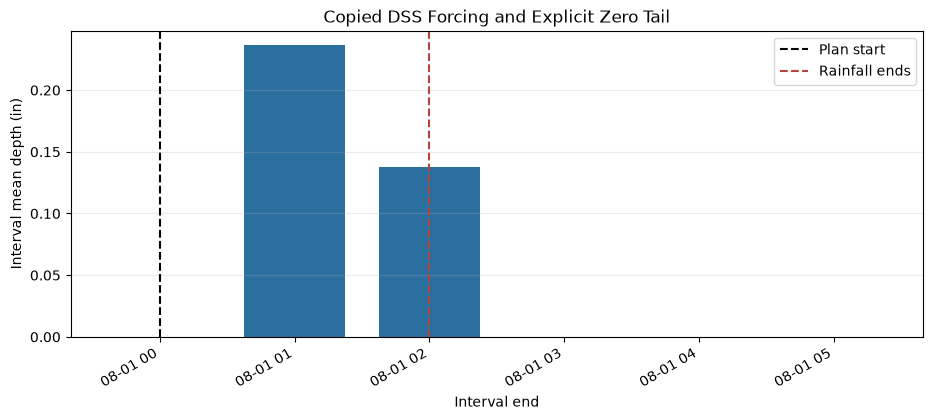

In [4]:
result = RasDss.copy_grid_with_zero_tail(
    source_dss=source_dss,
    output_dss=output_dss,
    pathname=SOURCE_FAMILY,
    tail_intervals=TAIL_INTERVALS,
    time_shift_minutes=0,
    output_pathname=OUTPUT_FAMILY,
    x_shift=0.0,
    y_shift=0.0,
    overwrite=False,
)
source_sha_after = sha256_file(source_dss)
assert source_sha_before == source_sha_after == result["source_sha256"]
assert result["source_record_count"] == 3
assert result["appended_record_count"] == TAIL_INTERVALS
assert RasDss.get_file_version(output_dss) == 7

output_catalog = RasDss.get_catalog(output_dss)
output_paths = sorted(output_catalog["pathname"].astype(str))
assert len(output_paths) == 6
assert not any("/UNRELATED/" in path.upper() for path in output_paths)
output_grids = [RasDss.read_grid(output_dss, path) for path in output_paths]
output_rows = []
for path, grid in zip(output_paths, output_grids):
    values = np.asarray(grid["data"], dtype=float)
    output_rows.append({
        "pathname": path,
        "start_time": pd.Timestamp(grid["start_time"]),
        "end_time": pd.Timestamp(grid["end_time"]),
        "mean_mm": float(np.nanmean(values)),
        "maximum_mm": float(np.nanmax(values)),
        "role": "zero tail" if path in result["appended_pathnames"] else "copied source",
    })
output_audit = pd.DataFrame(output_rows).sort_values("start_time").reset_index(drop=True)
for path in result["appended_pathnames"]:
    grid = RasDss.read_grid(output_dss, path)
    values = np.asarray(grid["data"], dtype=float)
    assert np.all(values[np.isfinite(values)] == 0.0)

display(pd.Series({
    "source SHA unchanged": source_sha_before == source_sha_after,
    "copied records": result["source_record_count"],
    "appended dry records": result["appended_record_count"],
    "copied forcing ends": result["output_source_end"],
    "zero tail ends": result["padded_end"],
    "derivative DSS": rel(output_dss),
}, name="derivative QA").to_frame())
display(output_audit)

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = output_audit["role"].map({"copied source": "#2b6f9f", "zero tail": "#b8c7d9"})
ax.bar(output_audit["end_time"], output_audit["mean_mm"] / 25.4,
       width=pd.Timedelta(minutes=45), color=colors)
ax.axvline(pd.Timestamp(simulation_start), color="black", linestyle="--", label="Plan start")
ax.axvline(pd.Timestamp(source_end), color="#b5453c", linestyle="--", label="Rainfall ends")
ax.set(title="Copied DSS Forcing and Explicit Zero Tail", xlabel="Interval end", ylabel="Interval mean depth (in)")
ax.grid(axis="y", alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.show()


## Attach the derivative to a copied HEC-RAS plan

The plan starts after the dry context record and ends with the final appended
zero record. `ratio=1.0` is explicit because older 6.x releases can otherwise
retain an ineffective ratio. The DSS setter also preserves explicit meteorology
choices and completes the required evapotranspiration, air-density, and
air-pressure modes. Runtime-message and HDF review below is still required.


In [5]:
extended_unsteady = RasPlan.clone_unsteady(
    TEMPLATE_UNSTEADY, new_title="Extended DSS Window", ras_object=ras
)
extended_plan = RasPlan.clone_plan(
    TEMPLATE_PLAN, new_plan_shortid="DSS Extend", new_title="Extended DSS Window",
    geometry=TEMPLATE_GEOMETRY, unsteady_flow=extended_unsteady, num_cores=4,
    intervals={"computation": "5SEC", "output": "10MIN", "mapping": "10MIN"},
    ras_object=ras,
)
simulation_end = pd.Timestamp(result["padded_end"]).to_pydatetime()
assert simulation_end == simulation_start + timedelta(hours=5)
RasPlan.update_simulation_date(
    extended_plan, simulation_start, simulation_end, ras_object=ras
)
RasUnsteady.configure_gridded_dss_precipitation(
    extended_unsteady,
    dss_filename=str(output_dss),
    dss_pathname=result["written_source_pathnames"][1],
    ratio=1.0,
    interpolation="Bilinear",
    ras_object=ras,
)
config = RasUnsteady.get_met_precipitation_config(extended_unsteady, ras_object=ras)
assert config["mode"] == "Gridded" and config["source"] == "DSS"
display(pd.Series({
    "plan": f"p{extended_plan}",
    "unsteady flow": f"u{extended_unsteady}",
    "simulation start": simulation_start,
    "rainfall end": source_end,
    "simulation/forcing end": simulation_end,
    "DSS records inside model window": 5,
}, name="HEC-RAS handoff").to_frame())


,HEC-RAS handoff
plan,p07
unsteady flow,u04
simulation start,2024-08-01 00:00:00
rainfall end,2024-08-01 02:00:00
simulation/forcing end,2024-08-01 05:00:00
DSS records inside model window,5


## Gold-standard temporary-HDF validation

Preprocessing materializes the solver input before compute. The two rainfall
rows and three appended dry rows are selected by their interval endpoints and
compared with the derivative DSS values.


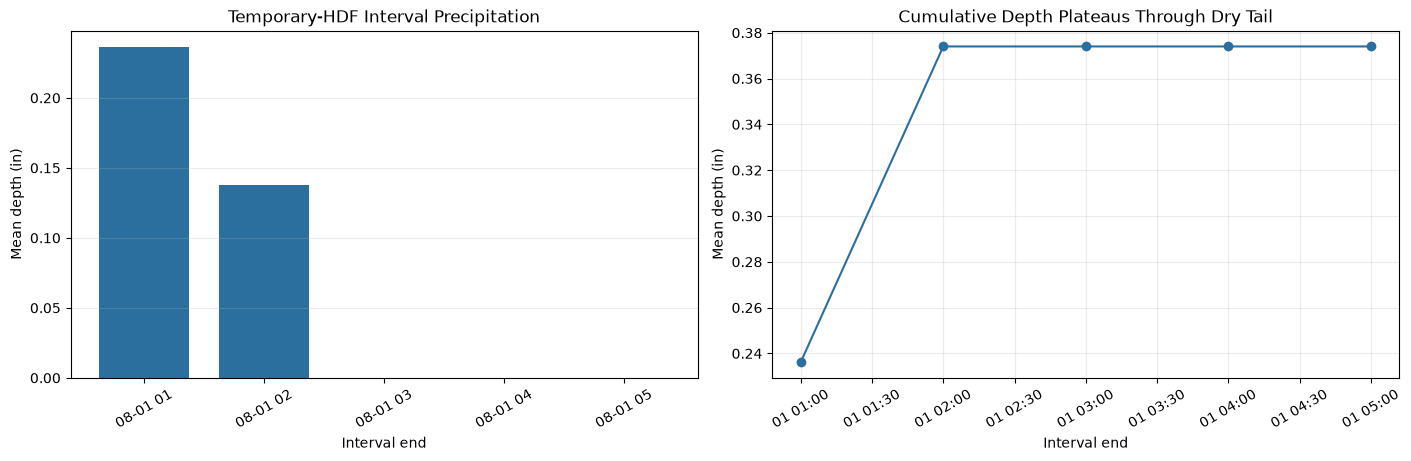

,temporary-HDF rows in model window,zero-tail rows,final mean depth (in),maximum DSS-to-precompute error (in)
0,5,3,0.374016,2.000000e-07


In [6]:
window_audit = output_audit.loc[
    (output_audit["start_time"] >= pd.Timestamp(simulation_start))
    & (output_audit["end_time"] <= pd.Timestamp(simulation_end))
].reset_index(drop=True)
assert len(window_audit) == 5
window_grids = [RasDss.read_grid(output_dss, path) for path in window_audit["pathname"]]
window_arrays = [np.asarray(grid["data"], dtype=float) for grid in window_grids]
expected_total = np.nansum(np.stack(window_arrays), axis=0)
assert np.allclose(np.stack(window_arrays[-TAIL_INTERVALS:]), 0.0)

prepared = RasPreprocess.preprocess_plan(extended_plan, ras_object=ras, max_wait=600)
if not bool(prepared):
    raise RuntimeError(prepared.error)
with h5py.File(prepared.tmp_hdf_path, "r") as hdf:
    solver_rainfall = hdf["Event Conditions/Meteorology/Precipitation/Values"][:]
    solver_timestamps = hdf["Event Conditions/Meteorology/Precipitation/Timestamp"][:]
solver_time = pd.DatetimeIndex(pd.to_datetime(
    [value.decode("ascii") for value in solver_timestamps],
    format="%d%b%Y %H:%M:%S.%f",
))
solver_window_mask = (solver_time > pd.Timestamp(simulation_start)) & (solver_time <= pd.Timestamp(simulation_end))
solver_window = solver_rainfall[solver_window_mask]
solver_window_time = solver_time[solver_window_mask]
assert solver_window.shape[0] == 5
assert np.allclose(solver_window[-TAIL_INTERVALS:], 0.0, atol=1e-9)
solver_cumulative = np.cumsum(solver_window, axis=0)
precompute_error = solver_cumulative[-1] - np.flipud(expected_total).reshape(-1) / 25.4
assert float(np.nanmax(np.abs(precompute_error))) <= 5e-6

fig, (ax_interval, ax_cumulative) = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
ax_interval.bar(solver_window_time, np.nanmean(solver_window, axis=1),
                width=pd.Timedelta(minutes=45), color=["#2b6f9f"] * 2 + ["#b8c7d9"] * 3)
ax_interval.set(title="Temporary-HDF Interval Precipitation", xlabel="Interval end", ylabel="Mean depth (in)")
ax_interval.tick_params(axis="x", rotation=30)
ax_interval.grid(axis="y", alpha=0.25)
ax_cumulative.plot(solver_window_time, np.nanmean(solver_cumulative, axis=1), marker="o", color="#2b6f9f")
ax_cumulative.set(title="Cumulative Depth Plateaus Through Dry Tail", xlabel="Interval end", ylabel="Mean depth (in)")
ax_cumulative.tick_params(axis="x", rotation=30)
ax_cumulative.grid(alpha=0.25)
plt.show()

display(pd.DataFrame([{
    "temporary-HDF rows in model window": solver_window.shape[0],
    "zero-tail rows": TAIL_INTERVALS,
    "final mean depth (in)": float(np.nanmean(solver_cumulative[-1])),
    "maximum DSS-to-precompute error (in)": float(np.nanmax(np.abs(precompute_error))),
}]).round(7))


## Compute and inspect the completed plan

The final plan HDF and BCO file are the post-compute records. The notebook
checks forcing coverage, source/final agreement on active cells, the dry-tail
plateau, runtime diagnostics, and the resulting hydraulic depth.


In [7]:
result_compute = RasCmdr.compute_plan(
    extended_plan, ras_object=ras, force_rerun=True, force_geompre=True,
    verify=True, use_optimal_hdf_settings=True,
    hdf_output_variables=[
        "Cell Hydraulic Depth", "Water Surface", "Cell Precipitation Rate",
        "Cell Cumulative Precipitation Depth",
    ],
)
if not bool(result_compute):
    raise RuntimeError("Extended DSS window compute failed")
plan_hdf = ras.project_folder / f"{ras.project_name}.p{extended_plan}.hdf"
messages = HdfResultsPlan.get_compute_messages_hdf_only(plan_hdf)
assert "complete process" in messages.lower()
assert not ("out-of-bounds" in messages.lower() and "2d cells" in messages.lower())

bco_path = ras.project_folder / f"{ras.project_name}.bco{extended_plan}"
assert bco_path.exists()
bco_text = bco_path.read_text(encoding="utf-8", errors="replace")
diagnostic_pattern = re.compile(
    r"\b(?:warning|fatal|failed|missing)\b|"
    r"\berror(?::|\s+(?:reading|opening|processing|computing|occurred|encountered))",
    flags=re.IGNORECASE,
)
problem_lines = [line.strip() for line in bco_text.splitlines() if diagnostic_pattern.search(line)]
assert not problem_lines, problem_lines

ws_error = HdfResultsMesh.get_mesh_max_ws_err(plan_hdf)
error_column = "cell_maximum_water_surface_error"
volume = HdfResultsPlan.get_volume_accounting(plan_hdf)
runtime_audit = pd.DataFrame([{
    "complete process": True,
    "precipitation coverage warning": False,
    "BCO diagnostic lines": len(problem_lines),
    "maximum cell WSEL error (ft)": float(ws_error[error_column].max()),
    "cells WSEL error >0.1 ft": int(np.count_nonzero(ws_error[error_column] > 0.1)),
    "volume error (%)": float(volume.iloc[0]["Error Percent"]),
}])
display(runtime_audit.round(6))


,complete process,precipitation coverage warning,BCO diagnostic lines,maximum cell WSEL error (ft),cells WSEL error >0.1 ft,volume error (%)
0,True,False,0,0.832132,2,0.008768


,DSS sampled mean (in),final-HDF active mean (in),DSS-to-final mean error (in),DSS-to-final RMSE (in),active cells,tail maximum rain rate
0,0.372329,0.372335,0.000005,0.000693,18066,0.0


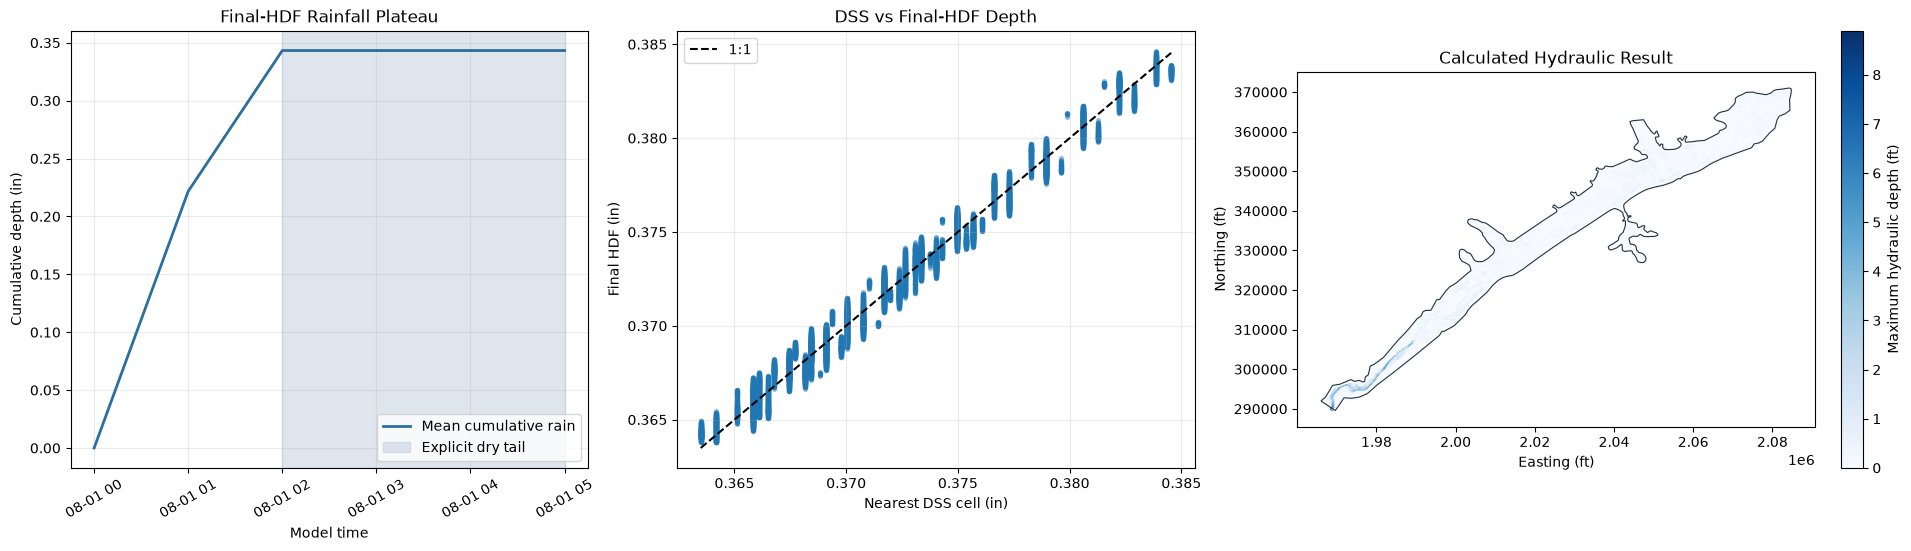

In [8]:
rate = HdfResultsMesh.get_mesh_timeseries(
    plan_hdf, MESH_NAME, "Cell Precipitation Rate", truncate=False
)
cumulative = HdfResultsMesh.get_mesh_timeseries(
    plan_hdf, MESH_NAME, "Cell Cumulative Precipitation Depth", truncate=False
)
depth = HdfResultsMesh.get_mesh_timeseries(
    plan_hdf, MESH_NAME, "Cell Hydraulic Depth", truncate=False
)
rate_values = np.asarray(rate.values, dtype=float)
cumulative_values = np.asarray(cumulative.values, dtype=float)
depth_values = np.asarray(depth.values, dtype=float)
final_cumulative = cumulative_values[-1]
active_mask = final_cumulative > 1e-6
assert int(np.count_nonzero(active_mask)) == mesh_cell_count

first_grid = window_grids[0]
origin_x_dss, origin_y_dss = first_grid["metadata"]["origin"]
grid_rows, grid_columns = first_grid["shape"]
mesh_in_dss = mesh_points.to_crs(first_grid["crs"])
sample_columns = np.floor((mesh_in_dss.geometry.x.to_numpy() - origin_x_dss) / CELL_SIZE_M).astype(int)
sample_rows = np.floor((mesh_in_dss.geometry.y.to_numpy() - origin_y_dss) / CELL_SIZE_M).astype(int)
inside = (
    (sample_columns >= 0) & (sample_columns < grid_columns)
    & (sample_rows >= 0) & (sample_rows < grid_rows)
)
sampled_dss = np.full(len(mesh_points), np.nan)
sampled_dss[inside] = expected_total[sample_rows[inside], sample_columns[inside]] / 25.4
comparison_mask = inside & active_mask & np.isfinite(sampled_dss) & np.isfinite(final_cumulative)
comparison_error = final_cumulative[comparison_mask] - sampled_dss[comparison_mask]
assert abs(float(np.nanmean(comparison_error))) <= 0.02
assert float(np.sqrt(np.nanmean(comparison_error ** 2))) <= 0.05

rate_time = pd.DatetimeIndex(pd.to_datetime(rate.coords["time"].values))
tail_time_mask = rate_time > pd.Timestamp(source_end)
assert np.isclose(np.nanmax(rate_values[tail_time_mask]), 0.0, atol=1e-9)
cumulative_tail = cumulative_values[tail_time_mask]
assert float(np.nanmax(np.abs(cumulative_tail - cumulative_tail[0]))) <= 1e-6

depth_values[depth_values < 0] = np.nan
with np.errstate(all="ignore"):
    maximum_depth = np.nanmax(depth_values, axis=0)
assert float(np.nanmax(maximum_depth)) > 0.0
depth_map = mesh_points.copy()
depth_map["maximum_depth_ft"] = maximum_depth

forcing_summary = pd.DataFrame([{
    "DSS sampled mean (in)": float(np.nanmean(sampled_dss[comparison_mask])),
    "final-HDF active mean (in)": float(np.nanmean(final_cumulative[comparison_mask])),
    "DSS-to-final mean error (in)": float(np.nanmean(comparison_error)),
    "DSS-to-final RMSE (in)": float(np.sqrt(np.nanmean(comparison_error ** 2))),
    "active cells": int(np.count_nonzero(active_mask)),
    "tail maximum rain rate": float(np.nanmax(rate_values[tail_time_mask])),
}])
display(forcing_summary.round(7))

fig, (ax_series, ax_scatter, ax_depth) = plt.subplots(1, 3, figsize=(19, 5.4), constrained_layout=True)
ax_series.plot(rate_time, np.nanmean(cumulative_values, axis=1), color="#2b6f9f", linewidth=2, label="Mean cumulative rain")
ax_series.axvspan(pd.Timestamp(source_end), pd.Timestamp(simulation_end), color="#b8c7d9", alpha=0.45, label="Explicit dry tail")
ax_series.set(title="Final-HDF Rainfall Plateau", xlabel="Model time", ylabel="Cumulative depth (in)")
ax_series.tick_params(axis="x", rotation=30)
ax_series.grid(alpha=0.25)
ax_series.legend()

ax_scatter.scatter(sampled_dss[comparison_mask], final_cumulative[comparison_mask], s=8, alpha=0.35)
limits = [float(np.nanmin(sampled_dss[comparison_mask])), float(np.nanmax(sampled_dss[comparison_mask]))]
ax_scatter.plot(limits, limits, color="black", linestyle="--", label="1:1")
ax_scatter.set(title="DSS vs Final-HDF Depth", xlabel="Nearest DSS cell (in)", ylabel="Final HDF (in)")
ax_scatter.grid(alpha=0.25)
ax_scatter.legend()

depth_map.plot(ax=ax_depth, column="maximum_depth_ft", cmap="Blues", markersize=5,
               legend=True, legend_kwds={"label": "Maximum hydraulic depth (ft)"})
HdfMesh.get_mesh_areas(geometry_hdf).boundary.plot(ax=ax_depth, color="#263238", linewidth=0.8)
ax_depth.set(title="Calculated Hydraulic Result", xlabel="Easting (ft)", ylabel="Northing (ft)")
ax_depth.set_aspect("equal")
plt.show()


## Completion record

The executable checks establish a reviewable forcing derivative and one real
model run. They do not approve the source product or replace manual HEC-RAS
diagnostics for a project model.


In [9]:
completion_checks = pd.Series({
    "source DSS remained byte-for-byte unchanged": source_sha_before == source_sha_after,
    "selected family copied without unrelated records": len(output_paths) == 6 and not any("/UNRELATED/" in path.upper() for path in output_paths),
    "three explicit zero-tail records appended": result["appended_record_count"] == 3,
    "temporary HDF matches DSS and contains dry tail": float(np.nanmax(np.abs(precompute_error))) <= 5e-6 and np.allclose(solver_window[-3:], 0.0),
    "HEC-RAS compute and runtime gates passed": bool(result_compute) and "complete process" in messages.lower() and not problem_lines,
    "final HDF preserves the dry-tail plateau": np.isclose(np.nanmax(rate_values[tail_time_mask]), 0.0, atol=1e-9),
    "DSS and active final-HDF depths agree": abs(float(np.nanmean(comparison_error))) <= 0.02 and float(np.sqrt(np.nanmean(comparison_error ** 2))) <= 0.05,
    "computed hydraulic result is positive": float(np.nanmax(maximum_depth)) > 0.0,
}, name="passed").to_frame()
display(completion_checks)
assert completion_checks["passed"].all()

print("DSS forcing-window extension qualification complete.")
print(f"HEC-RAS {RAS_VERSION}; plan p{extended_plan}; rainfall ends {source_end}; dry tail ends {simulation_end}.")
print("Review all HEC-RAS runtime and BCO messages, forcing pathnames/maps, timing, units, convergence, mass balance, and hydraulic plausibility manually.")


,passed
source DSS remained byte-for-byte unchanged,True
selected family copied without unrelated records,True
three explicit zero-tail records appended,True
temporary HDF matches DSS and contains dry tail,True
HEC-RAS compute and runtime gates passed,True
final HDF preserves the dry-tail plateau,True
DSS and active final-HDF depths agree,True
computed hydraulic result is positive,True


DSS forcing-window extension qualification complete.
HEC-RAS 7.0; plan p07; rainfall ends 2024-08-01 02:00:00; dry tail ends 2024-08-01 05:00:00.
Review all HEC-RAS runtime and BCO messages, forcing pathnames/maps, timing, units, convergence, mass balance, and hydraulic plausibility manually.
